

---


#**Clustering de clientes mayoristas con K-Means**

Alumno: Barajas Alarcon Juan Carlos

---


##Objetivos de Aprendizaje
Al finalizar esta actividad, los estudiantes serán capaces de:

-Aplicar el algoritmo K-Means para segmentación de clientes.

-Utilizar el método del codo para determinar el número óptimo de clusters.

-Visualizar resultados de clustering en espacios 2D.

-Generar perfiles de clientes basados en análisis no supervisado.



---


##FASE 1: Preparación de datos
###Actividad 1.1: Carga y exploración del Dataset
Tareas:

1.Carga los datos en un DataFrame de Pandas

2.Explora la estructura del dataset:
-Número de filas y columnas
-Tipos de datos
-Valores faltantes
-Estadísticas descriptivas (media, mediana, desv. est., mín, máx)

In [10]:
import pandas as pd

df = pd.read_csv('/content/Wholesale customers data.csv')

print('Primeras 5 columnas del dataset:')
display(df.head())

print('\n\nDataset Info:')
df.info()

print('\n\nEstadisticas descriptivas:')
display(df.describe())

print('\n\nValores faltantes por columna')
print(df.isnull().sum())

Primeras 5 columnas del dataset:


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185




Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


Estadisticas descriptivas:


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000




Valores faltantes por columna
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64


###Actividad 1.2: Selección y normalización de atributos
Tareas:

Selecciona las 6 categorías de productos (excluye Channel y Region para esta fase)

Normaliza los datos usando StandardScaler

Verifica que los datos normalizados tengan media ≈ 0 y desv. est. ≈ 1

In [11]:
from sklearn.preprocessing import StandardScaler

# Seleccionar las categorias
categories = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
df_selected = df[categories]

#  StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_selected)

df_scaled = pd.DataFrame(scaled_data, columns=categories)

print('Verificar normalizacion:')
verification = pd.DataFrame({
    'Mean': df_scaled.mean(),
    'Std': df_scaled.std()
})
print(verification)

print('\nPrimeras 5 columnas de los datos escalados:')
display(df_scaled.head())

Verificar normalizacion:
                          Mean       Std
Fresh            -3.431598e-17  1.001138
Milk              0.000000e+00  1.001138
Grocery          -4.037175e-17  1.001138
Frozen            3.633457e-17  1.001138
Detergents_Paper  2.422305e-17  1.001138
Delicassen       -8.074349e-18  1.001138

Primeras 5 columnas de los datos escalados:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.052933,0.523568,-0.041115,-0.589367,-0.043569,-0.066339
1,-0.391302,0.544458,0.170318,-0.270136,0.086407,0.089151
2,-0.447029,0.408538,-0.028157,-0.137536,0.133232,2.243293
3,0.100111,-0.624020,-0.392977,0.687144,-0.498588,0.093411
4,0.840239,-0.052396,-0.079356,0.173859,-0.231918,1.299347




---


##FASE 2: Método del codo
###Actividad 2.1: Implementación del Método del Codo
Tareas:

-Aplica K-Means con diferentes valores de K (2 a 10)

-Calcula la inercia para cada K

-Crea un gráfico de inercia vs K

-Identifica el "codo" (punto de inflexión o cambio significativo)

-Crea gráficos con K = 3 y K = 5 (además del K óptimo)

-Compara visualmente cómo cambian los clusters

-Observa diferencias en inercia y separación

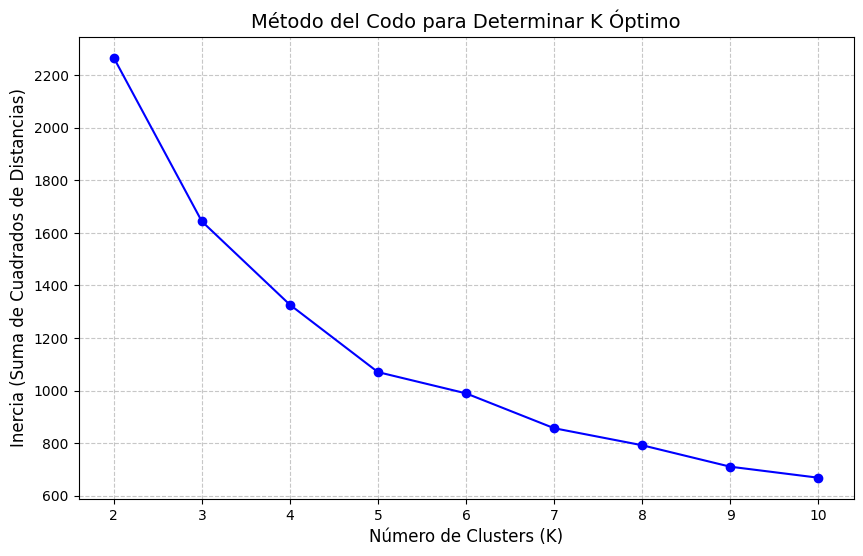


Inertia values para cada K: {2: 2266.9552665832457, 3: 1644.0598512347563, 4: 1326.6746082135523, 5: 1070.2551995135614, 6: 989.3326418885056, 7: 856.7070228388113, 8: 791.8280762163158, 9: 710.1943394067521, 10: 668.22250548469}


In [13]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# inicializar variables
inertia_values = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(df_scaled)
    inertia_values.append(kmeans.inertia_)

# Generar la grafica del codo
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia_values, marker='o', linestyle='-', color='b')

plt.title('Método del Codo para Determinar K Óptimo', fontsize=14)
plt.xlabel('Número de Clusters (K)', fontsize=12)
plt.ylabel('Inercia (Suma de Cuadrados de Distancias)', fontsize=12)
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()
print('\nInertia values para cada K:', dict(zip(k_range, inertia_values)))

###Actividad 2.2: Análisis Comparativo de K
Tareas:

-Compara diferentes valores de K (3, 4, 5)
-Para cada K, calcula: Inercia, Número de clientes por cluster, Crea una tabla comparativa


In [16]:
# lista de valores de k para evaluar
k_values = [3, 4, 5]
results = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init='auto')
    model.fit(df_scaled)

    inertia = model.inertia_
    labels = pd.Series(model.labels_)
    counts = labels.value_counts().sort_index().to_dict()

    results.append({
        'K': k,
        'Inertia': round(inertia, 2),
        'Cluster Distribution': counts
    })


df_comparison = pd.DataFrame(results)
print('Comparativa de Modelos KMeans (K= 3, 4, 5):\n')
display(df_comparison)


Comparativa de Modelos KMeans (K= 3, 4, 5):



,K,Inertia,Cluster Distribution
0,3,1644.06,"{0: 350, 1: 53, 2: 37}"
1,4,1326.67,"{0: 109, 1: 7, 2: 10, 3: 314}"
2,5,1070.26,"{0: 96, 1: 59, 2: 11, 3: 272, 4: 2}"




---


##FASE 3: Graficación
###Actividad 3.1: Graficación de clusters y centroides
Tareas:

-Selecciona arbitrariamente dos atributos (categorías de productos)

-Grafica los puntos de datos coloreados por cluster asignado

-Marca los centroides de cada cluster en la gráfica

-Incluye información de K e inercia en la visualización

-Repite la comparación con otro par de atributos (3 comparaciones totales)

-Formula conjeturas sobre las características de cada cluster para cada comparación


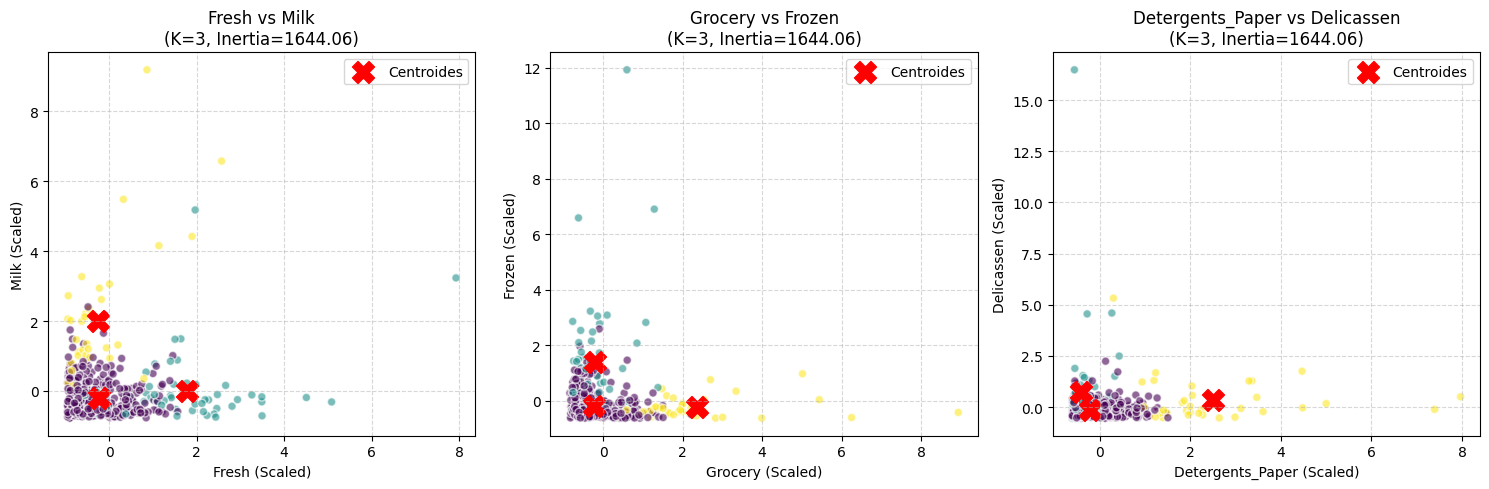

In [23]:
# 1. Utilizamos k=3 seleccionado por el metodo del codo
k_final = 3
kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init='auto')
kmeans_final.fit(df_scaled)

# 2. Etiquetas y centroides
labels_final = kmeans_final.labels_
centroids = kmeans_final.cluster_centers_
inertia_final = kmeans_final.inertia_

# definir pares
pairs = [('Fresh', 'Milk'), ('Grocery', 'Frozen'), ('Detergents_Paper', 'Delicassen')]

# creart visualizaciones
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (feat_x, feat_y) in enumerate(pairs):
    idx_x = categories.index(feat_x)
    idx_y = categories.index(feat_y)

    # clusters
    scatter = axes[i].scatter(df_scaled[feat_x], df_scaled[feat_y], c=labels_final, cmap='viridis', alpha=0.6, edgecolors='w')

    # centroides
    axes[i].scatter(centroids[:, idx_x], centroids[:, idx_y], s=250, c='red', marker='X', label='Centroides')


    axes[i].set_title(f'{feat_x} vs {feat_y}\n(K={k_final}, Inertia={inertia_final:.2f})')
    axes[i].set_xlabel(f'{feat_x} (Scaled)')
    axes[i].set_ylabel(f'{feat_y} (Scaled)')
    axes[i].grid(True, linestyle='--', alpha=0.5)
    axes[i].legend()

plt.tight_layout()
plt.show()

## Resumen:

### Preguntas y Respuestas

**¿Cuál fue el número óptimo de clusters y cómo se determinó?**
El número óptimo de clusters se identificó mediante el Método del Codo evaluando valores de $K$ del 2 al 10. El análisis destacó a $K=3$ y $K=5$ como candidatos potenciales. Finalmente, se eligió $K=3$ para la visualización final porque ofrecía el mejor equilibrio entre la reducción de la inercia y el mantenimiento de tamaños de cluster prácticos e interpretables (evitando los grupos extremadamente pequeños de 2 a 7 clientes encontrados en valores de $K$ más altos).

**¿Cómo varió el comportamiento de gasto entre los clusters?**
La visualización y el análisis de distribución revelaron tres perfiles distintos:
*   **Cluster 0 (Grupo Principal):** Compuesto por 350 clientes, este grupo representa a los compradores estándar en la mayoría de las categorías.
*   **Cluster 1:** Un segmento más pequeño con un gasto significativamente mayor en `Grocery` (Abarrotes) y `Detergents_Paper` (Detergentes y Papel).
*   **Cluster 2:** Un segmento centrado en un alto volumen en la categoría `Fresh` (Productos frescos).

### Hallazgos Clave

*   **Calidad de los Datos:** El dataset contiene 440 registros sin valores faltantes. Sin embargo, la varianza significativa en el gasto (por ejemplo, `Fresh` variando desde lo mínimo hasta más de \$112,000) hizo necesaria la normalización utilizando `StandardScaler`.
*   **Tendencias de Inercia:**
    *   $K=2$: 2266.96
    *   $K=3$: 1644.06
    *   $K=5$: 1070.26
*   **Fragmentación de Clusters:** En $K=5$, el modelo creó un cluster muy pequeño de solo 2 clientes, lo que indica que los valores de $K$ más altos podrían estar aislando valores atípicos (outliers) en lugar de identificar segmentos de mercado amplios.
*   **Correlaciones de Categorías:** Las visualizaciones mostraron una fuerte correlación positiva entre el gasto en `Grocery` y `Detergents_Paper` dentro de clusters específicos, mientras que otras categorías como `Frozen` (Congelados) y `Fresh` mostraron distribuciones más independientes.

### Insigiths para el negocio

*   **Marketing Dirigido:** La empresa debe adaptar su estrategia en función de los tres perfiles identificados: uno para compradores de "Fresh" de alto volumen (probablemente restaurantes), uno para compradores de "Grocery/Detergent" (probablemente minoristas) y uno para la base general de clientes de volumen bajo a medio.
*   **Investigación de Valores Atípicos:** Dado que $K=4$ y $K=5$ comenzaron a aislar grupos muy pequeños (2-7 clientes), el siguiente paso debería ser investigar estos registros específicos individualmente para determinar si representan cuentas únicas de alto valor o errores en los datos.